# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.


In [69]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [70]:
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


También está disponible: imagen_preprocesada.png
Imágenes listas para la actividad.


## Parte 1. Elegí una imagen y un color objetivo

Si completaste el cuaderno extra de preprocesamiento, te conviene empezar con `imagen_preprocesada.png`. Si no, podés trabajar con `flowers.jpg` o con `frutos_rojos.png`.

Antes de escribir código, anotá qué color querés segmentar y por qué te parece un buen caso para probar.


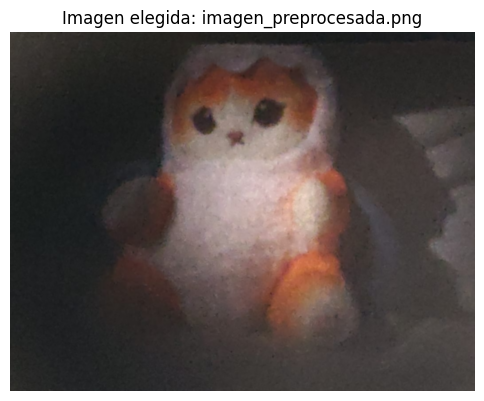

Color objetivo: Naranja


In [71]:
# Elegí la imagen con la que vas a trabajar.
if Path("imagen_preprocesada.png").exists():
    nombre_imagen = "imagen_preprocesada.png"
else:
    nombre_imagen = "flowers.jpg"  # o "frutos_rojos.png"

imagen_rgb = cargar_rgb(nombre_imagen)

# Escribí en una frase qué color querés segmentar.
color_objetivo = "Naranja"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)


## Parte 2. Explorá canales e histogramas

Antes de definir umbrales, mirá la imagen por canales y revisá sus histogramas. La pregunta clave es: ¿qué canal parece más útil para distinguir el color que querés aislar?


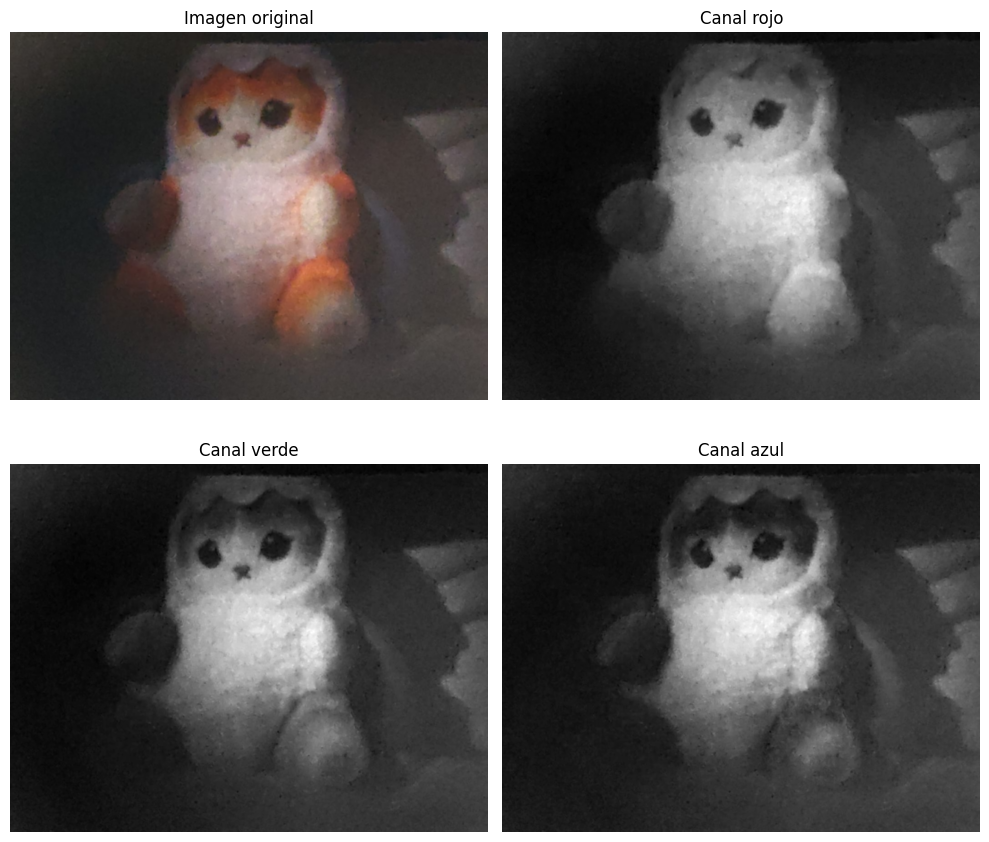

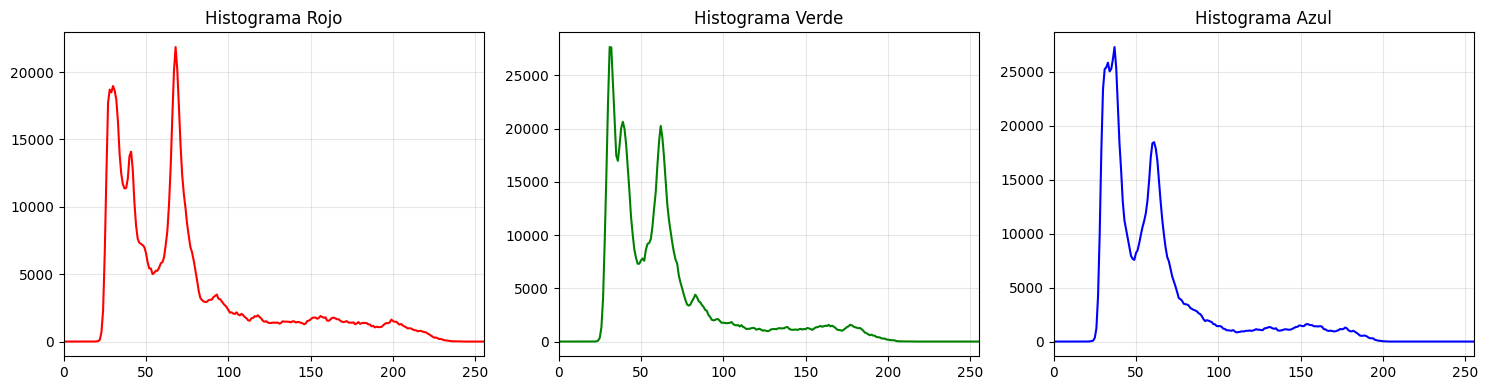

El canal rojo es el más útil para aislar el color naranja, ya que este color tiene una fuerte componente en rojo. En este canal, las zonas naranjas del objeto se ven más intensas y diferenciadas del fondo. En cambio, los canales verde y azul muestran menos contraste en esas regiones, por lo que resultan menos efectivos para segmentar ese color.


In [72]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)

# Escribí una observación breve sobre lo que viste.
observacion = "El canal rojo es el más útil para aislar el color naranja, ya que este color tiene una fuerte componente en rojo. " \
"En este canal, las zonas naranjas del objeto se ven más intensas y diferenciadas del fondo. " \
"En cambio, los canales verde y azul muestran menos contraste en esas regiones, por lo que resultan menos efectivos para segmentar ese color."
print(observacion)


## Parte 3. Diseñá tu primera estrategia de segmentación

Completá los rangos mínimos y máximos para cada canal. No tienen por qué ser perfectos en el primer intento. La idea es que puedas probar, mirar y corregir.


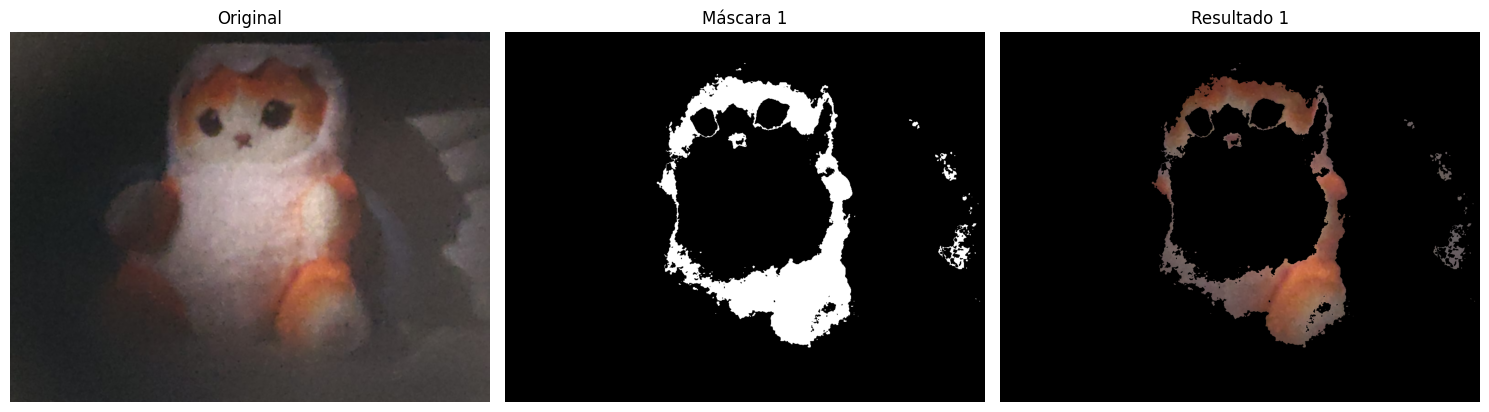

In [73]:
r_min, r_max = 100, 255
g_min, g_max = 50, 200
b_min, b_max = 0, 100

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Parte 4. Revisá y mejorá

Proponé una segunda estrategia. Puede cambiar solo un parámetro o varios. Después compará ambos resultados y explicá cuál conservarías.


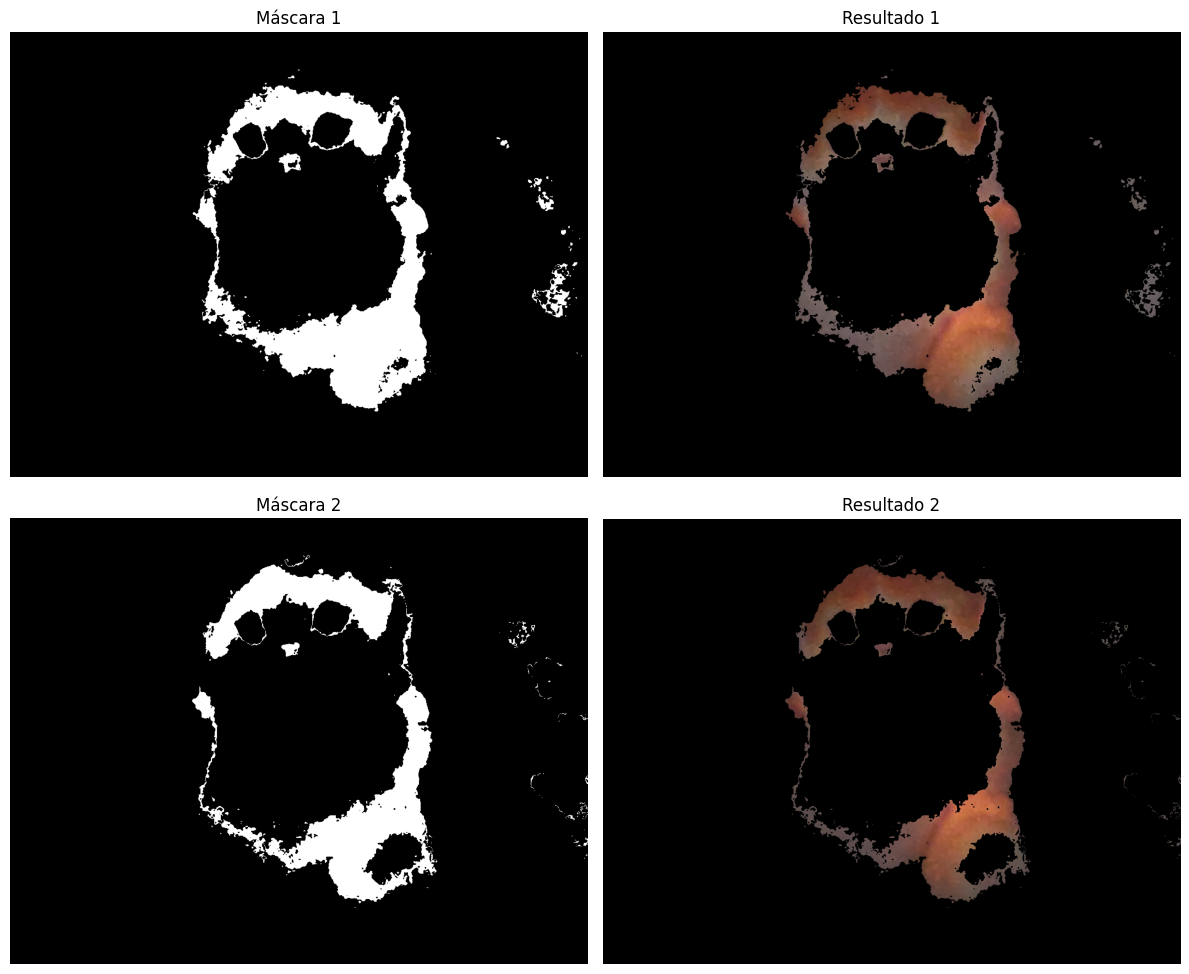

La segunda estrategia utiliza umbrales más estrictos, lo que reduce el ruido y mejora la limpieza de la segmentación. La máscara 2 presenta menos píxeles aislados del fondo, logrando una segmentación más precisa. Sin embargo, también pierde algunas regiones del objeto que sí corresponden al color naranja. En comparación, la máscara 1 conserva más información pero incluye más ruido. Por lo tanto, elegiría la estrategia 2 si se prioriza una segmentación más limpia.


In [74]:
r_min_2, r_max_2 = 90, 255
g_min_2, g_max_2 = 30, 130
b_min_2, b_max_2 = 10, 80

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

observacion_final = "La segunda estrategia utiliza umbrales más estrictos, lo que reduce el ruido y mejora la limpieza de la segmentación. " \
"La máscara 2 presenta menos píxeles aislados del fondo, logrando una segmentación más precisa. " \
"Sin embargo, también pierde algunas regiones del objeto que sí corresponden al color naranja. " \
"En comparación, la máscara 1 conserva más información pero incluye más ruido. " \
"Por lo tanto, elegiría la estrategia 2 si se prioriza una segmentación más limpia."

print(observacion_final)

## Parte 5. Cierre escrito

Respondé con tus palabras:

1. ¿Qué color intentaste segmentar?
Se intento segmentar el color Naranja ya que en la imagen se vio como el más predominante.

2. ¿Qué canales te dieron la pista más útil?
El canal Rojo por ser el más cercano al color que quería segmentar.

3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia?
En la segunda estrategia se bajó el mínimo del canal rojo de 100 a 90 para incluir tonos naranjas más oscuros. Se redujo el rango del canal verde, pasando de 50–200 a 30–130, para evitar captar colores más cercanos al amarillo o al fondo. Además, se ajustó el canal azul, subiendo su mínimo de 0 a 10 y bajando su máximo de 100 a 80, con el objetivo de eliminar ruido y tonos fríos no deseados. En conjunto, estos cambios hacen que la segmentación sea más selectiva y limpia.

4. ¿Qué limitaciones encontraste en este método?
Me encontré que el método depende mucho de la iluminación de la imagen, cambios de iluminación hacen que el color no caiga dentro de los umbrales definidos. Además, el color naranja no es uniforme en toda la imagen, por lo que alguunas partes quedaron fuera de la segmentación o no se incluyeron en su totalidad. También se nota un poco de ruido de fondo, que si lo intentara reducir, perdería segmentos de la imagen importantes. Por último, al tener que ir ajustando los umbrales manualmente, es dificil encontrar una combinación óptima.

5. Si tuvieras más tiempo, ¿qué mejorarías?
Consideraría métodos más avanzados de segmentación o incluso modelos basados en aprendizaje automático, que permitirían generalizar mejor a distintas imágenes sin necesidad de ajustar parámetros manualmente.

### Lista de control antes de entregar

- Mostré la imagen original. 
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.
